# Capstone 2: EmporiUm Sales/Marketing Analysis

## Author: Naomi Tewolde 

## Sales Territory: 
### Region: Northeast
### States: Maine & Massachusetts

## Project Overview

In [48]:
# As part of this project, I conducted a business analysis for EmporiUm to better 
# understand sales performance across my assigned territories, the Northeast region
# (Maine and Massachusetts). My goal was to provide clear, data-driven insights that 
# can support your marketing decisions and help identify opportunities to improve sales
# performance. Using Python, Jupyter Notebook, and a structured analysis, I worked through
# the full process of cleaning, analyzing, and visualizing the data to highlight meaningful 
# patterns and comparisons between the territories.

## ---------------------------------------------------------------------------------------------------------------------------------------------------

In [49]:
# Importing essential libraries for data analysis and visualization

import numpy as np        # for fast numerical computations
import pandas as pd      # for organizing and analyzing data in tables
import matplotlib.pyplot as plt  # for creating charts and visual insights
from sklearn.linear_model import LinearRegression # creates regression model

## ---------------------------------------------------------------------------------------------------------------------------------------------------

## Loading CSV Files: 
##### Store Sales, Store Detail, Product Categories, Customer List, & Products

#### Store detail CSV file:

In [50]:
store_detail = pd.read_csv("StoreDetail.csv") # Importing/loading data

store_detail.info() # confirms the column names, number of non-null records, and dtype for each column 

store_detail.head() # Previewing DataFrame of top 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [51]:
store_detail.tail() # Previewing DataFrame of last 5

,Store Location,State,Store ID,Territory Manager,Region,Region Director
106,Dallas,Texas,907,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
107,Denton,Texas,908,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
108,Desoto,Texas,909,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
109,Fort Worth,Texas,910,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
110,Georgetown,Texas,911,"Jeff ""Howdy"" Richards",South,Andy Gisselquist


#### Store sales CSV file:

In [52]:
store_sales = pd.read_csv("StoreSales.csv") # Importing/loading data

store_sales.info() # confirms the column names, number of non-null records, and dtype for each column

store_sales.head() # Previewing DataFrame of top 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [53]:
store_sales.tail() # Previewing DataFrame of last 5

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
335124,12/31/2025,909,NaN,105353-A,20.36
335125,12/31/2025,909,332.0,105364-S,17.70
335126,12/31/2025,910,NaN,105672-B,26.52
335127,12/31/2025,910,NaN,105653-M,11.00
335128,12/31/2025,910,NaN,105300-IT,77.81


#### Products CSV file:

In [54]:
products = pd.read_csv("Products.csv") # Importing/loading data

products.info() # confirms the column names, number of non-null records, and dtype for each column

products.head() # Previewing DataFrame of top 5

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [55]:
products.tail() # Previewing DataFrame of last 5

,Prod Num,Product,CategoryID,SubcategoryID
664,105912-T,Networking Fundamentals,100,100-tec
665,105913-T,Introduction to Databases,100,100-tec
666,105914-IT,SanDisk Extreme Portable SSD (1TB),120,120-ext
667,105915-M,LTCA Year Up Spiral Notebook (Black),130,130-off
668,105916-M,LTCA Year Up Sunglasses (Black),130,130-acc


#### Customer list CSV file: 

In [56]:
customer_list = pd.read_csv("customer_list.csv") # Importing/loading data

customer_list.info() # confirms the column names, number of non-null records, and dtype for each column

customer_list.head() # Previewing DataFrame of top 5 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    object
dtypes: object(1)
memory usage: 4.2+ KB


,cust_id|date|time|name|email|phone|sms-opt-out
0,1|2023-03-15|08:45:12|Rachel|rachel@centralper...
1,2|2023-05-22|12:30:45|R. Geller|rossg@centralp...
2,3|2023-07-09|18:15:27|Monica Geller|chefmonica...
3,4|2023-09-01|21:05:33|Chandler Bing|chandlerb@...
4,5|2023-11-18|14:22:10|Joey|howyoudoing@central...


In [57]:
customer_list.tail() # Previewing DataFrame of last 5 

,cust_id|date|time|name|email|phone|sms-opt-out
516,517|2024-02-15|11:30:30|Perry the Platypus|age...
517,518|2024-05-01|15:55:45|Baljeet|baljeet@danvil...
518,519|2023-03-05|09:20:00|Buford|buford@danville...
519,520|2023-05-18|13:45:15|Vanessa D.|vanessa@dan...
520,521|2023-08-01|18:10:30|Linda Flynn-Fletcher|l...


#### Product Categories CSV file:

In [58]:
productcategories = pd.read_csv("productcategories.csv") # Importing/loading data

productcategories.info() # confirms the column names, number of non-null records, and dtype for each column

productcategories.head() # Previewing DataFrame of top 5 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [59]:
productcategories.tail() # Previewing DataFrame of last 5 

,CategoryID,Category,SubcategoryID,Subcategory
47,110,Stationery and Supplies,110-pen,Pencils and Erasers
48,110,Stationery and Supplies,110-pap,Paper Products
49,125,Books (General),125-ref,Reference Materials
50,115,Art Supplies,115-pal,Palettes and Mixing Tools
51,115,Art Supplies,115-eas,Easels and Storage


## ----------------------------------------------------------------------------------------------------------------------------------------------

# Core Marketing Analysis: 

## Q1: Territory managers and assigned store locations

In [60]:
# This question is asking me to identify who the territory managers are for the given sales
# territories and determine which stores belong to each territory. We
# need to list the store IDs and the cities where those stores are located, along with 
# the manager responsible for that territory, so it’s clear how stores are assigned and
# managed within each region.

In [61]:
# Filtering stores in Maine and Massachusetts with manager and location info

territory_stores = store_detail[(store_detail['State'] == 'Maine')| 
                                 (store_detail['State'] == 'Massachusetts')] 
                                 
# displaying columns and rows in this order
territory_stores[['Store ID', 'Store Location', 'Territory Manager', 'State']]

,Store ID,Store Location,Territory Manager,State
37,818,Bangor,Erbayne Middleton,Maine
38,819,Bar Harbor,Erbayne Middleton,Maine
39,820,Kennebunkport,Erbayne Middleton,Maine
40,821,Lewiston,Erbayne Middleton,Maine
41,822,Orono,Erbayne Middleton,Maine
42,823,South Portland,Erbayne Middleton,Maine
52,730,Boston,Bo Heap,Massachusetts
53,801,Attleboro,Bo Heap,Massachusetts
54,802,Falmouth,Bo Heap,Massachusetts
55,803,Framingham,Bo Heap,Massachusetts


## -------------------------------------------------------------------------------------------------------------------------------------------------

## Q2: Monthly Total Revenue for In-Store Sales

In [62]:
# This code calculates the monthly total in-store revenue for Maine and Massachusetts 
# by merging sales data with store location data from the matching column "store Id", 
# filtering for the selected states, and grouping by state and month.

In [63]:
# converting "Transaction Date" column to datetime
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# creating Month column
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M')

# merge in State info from store_detail
sales_with_state = store_sales.merge(
    store_detail[['Store ID', 'State']],
    on='Store ID')

# filter for Maine and Massachusetts
territory_sales = sales_with_state[
    (sales_with_state['State'] == 'Maine') |
    (sales_with_state['State'] == 'Massachusetts')]

# group by State, Month, and calculate total revenue
monthly_revenue = territory_sales.groupby(
    ['State', 'Month']
)['Sale Amount'].sum().reset_index()

# display results
monthly_revenue

,State,Month,Sale Amount
0,Maine,2022-01,15700.31
1,Maine,2022-02,21008.29
2,Maine,2022-03,23173.23
3,Maine,2022-04,20169.19
4,Maine,2022-05,22631.11
...,...,...,...
91,Massachusetts,2025-08,174867.46
92,Massachusetts,2025-09,168503.25
93,Massachusetts,2025-10,277382.19
94,Massachusetts,2025-11,196108.93


### Line graph for Monthly Total Revenue for Maine and Massachusetts

##### This graph shows the monthly total in-store revenue for Maine and Massachusetts, allowing for comparison of sales trends over time between the two states.

In [64]:
# reshape DataFrame for plotting
pivot_table = monthly_revenue.pivot(
    index='Month',
    columns='State',
    values='Sale Amount')

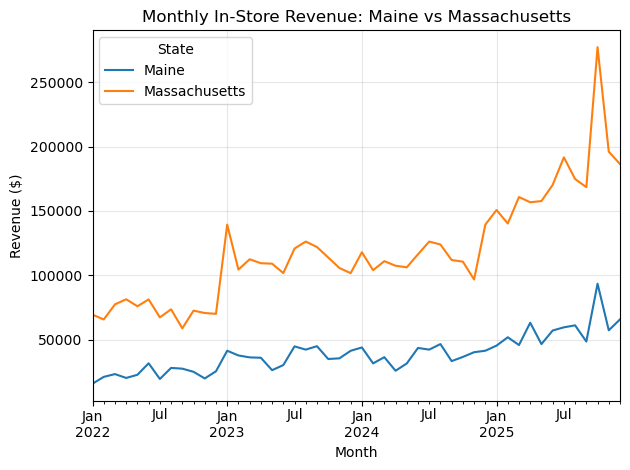

In [65]:
pivot_table.plot()  

plt.title("Monthly In-Store Revenue: Maine vs Massachusetts")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.legend(title="State")

plt.grid(alpha=0.3)  # adds light gridlines

plt.tight_layout()

plt.show()

#### Analysis:
##### Massachusetts consistently generates significantly higher revenue than Maine. The gap between the two states
##### increases over time, indicating that Massachusetts is outperforming Maine by a growing margin.
##### However, the scale of revenue is much larger in Massachusetts, highlighting stronger market performance in that territory.
##### Maine shows a more stable and moderate revenue trend, with lower overall revenue totals.
##### In contrast, Massachusetts demonstrates higher variability and growth, with noticeable increases and larger revenue spikes across several months.
##### The graph also reveals fluctuations across months, which could be influenced by seasonal shopping trends, promotional periods, or High-value product sales.
##### Overall, the trend suggests that while both states are impacted by similar external factors, like for example the holiday season,
##### Massachusetts dominates in total revenue and shows stronger growth, whereas Maine maintains steady but comparatively lower sales.

## ---------------------------------------------------------------------------------------------------------------------------------------------------

## Q3: Ranking Store Performance

In [66]:
# This code processes sales data by converting dates, merging in store location
# and state information, and filtering for Maine and Massachusetts. It then calculates 
# total revenue for each store, ranks the stores within each state based on performance,
# and organizes the results from highest to lowest revenue.

In [67]:
# converting Transaction Date column to datetime
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# merge in State + Store Location
sales_with_info = store_sales.merge(
    store_detail[['Store ID', 'State', 'Store Location']],
    on='Store ID')

# filter for Maine and Massachusetts
territory_sales = sales_with_info[
    (sales_with_info['State'] == 'Maine') |
    (sales_with_info['State'] == 'Massachusetts')]

# group by State, Store ID, and Location
store_performance = territory_sales.groupby(
    ['State', 'Store ID', 'Store Location']
)['Sale Amount'].sum().reset_index()

# rank stores within each state (1 = highest revenue)
store_performance['Rank'] = store_performance.groupby('State')['Sale Amount'].rank(
    ascending=False, method='dense')

# sort results
store_performance = store_performance.sort_values(['State', 'Rank'])

### Maine Store Ranking

In [68]:
maine_stores = store_performance[store_performance['State'] == 'Maine']
maine_stores

,State,Store ID,Store Location,Sale Amount,Rank
5,Maine,823,South Portland,332611.76,1.0
4,Maine,822,Orono,330505.47,2.0
2,Maine,820,Kennebunkport,321998.55,3.0
3,Maine,821,Lewiston,303761.91,4.0
0,Maine,818,Bangor,300919.98,5.0
1,Maine,819,Bar Harbor,287452.08,6.0


#### Top Performing Store | Maine:	
##### Store Id: 823
##### Store location: South Portland	
##### Total Revenue: $332,611.76

#### Analysis:
##### The spread between the highest and lowest top-ranked store is not extreme, 
##### indicating that revenue is evenly distributed across major Maine locations rather 
##### than being dominated by a single store. This pattern suggests consistent customer
##### demand and stable performance across the state.

### Massachusetts Store Ranking

In [69]:
mass_stores = store_performance[store_performance['State'] == 'Massachusetts']
mass_stores

,State,Store ID,Store Location,Sale Amount,Rank
23,Massachusetts,817,Worcester,602183.44,1.0
13,Massachusetts,807,Leominster,338009.10,2.0
16,Massachusetts,810,Nantucket,335547.81,3.0
20,Massachusetts,814,Provincetown,328860.51,4.0
18,Massachusetts,812,Northampton,322039.24,5.0
12,Massachusetts,806,Holyoke,320516.53,6.0
22,Massachusetts,816,Somerville,312873.59,7.0
10,Massachusetts,804,Haverhill,305762.60,8.0
15,Massachusetts,809,Lynn,302049.65,9.0
19,Massachusetts,813,Pittsfield,301281.50,10.0


#### Top Performing Store | Massachusetts:	
##### Store Id: 817	
##### Store location: Worcester	
##### Total Revenue: $602,183.44

#### Analysis:
##### The analysis shows that Massachusetts substantially outperforms Maine in 
##### store-level revenue, driven largely by high-performing locations such as Worcester.
##### While Maine demonstrates consistent and balanced store performance, Massachusetts
##### benefits from both higher overall revenue and the presence of standout stores, 
##### indicating a stronger and more dynamic market.

## ----------------------------------------------------------------------------------------------------------------------------------------------

## Q4: Top Customers in Each Sales Territory

In [70]:
# This code identifies the top customers in Maine and Massachusetts by matching
# customer IDs with rewards IDs, calculating total spending, and ranking customers 
# within each state based on their purchase amounts.

In [71]:
# clean customer_list (split column)
customer_list = customer_list.iloc[:, 0].str.split('|', expand=True)

customer_list.columns = [
    'Customer ID','Date','Time','Name','Email','Phone','SMS Opt Out']

# convert Customer ID to int 
customer_list['Customer ID'] = pd.to_numeric(customer_list['Customer ID'])

# rename RewardsID to Customer ID
store_sales = store_sales.rename(columns={'RewardsID': 'Customer ID'})

# convert Customer ID in store_sales to int
store_sales['Customer ID'] = pd.to_numeric(store_sales['Customer ID'])

# merge sales with customers
sales_w_customers = store_sales.merge(
    customer_list[['Customer ID', 'Name']],
    on='Customer ID')

# merge in State info
sales_w_state = sales_w_customers.merge(
    store_detail[['Store ID', 'State']],
    on='Store ID')

territory_sales = sales_w_state[
    (sales_w_state['State'] == 'Maine') |
    (sales_w_state['State'] == 'Massachusetts')]

# group by customer + state (total spending)
customer_performance = territory_sales.groupby(
    ['State', 'Customer ID', 'Name']
)['Sale Amount'].sum().reset_index()

# rank customers within each state
customer_performance['Rank'] = customer_performance.groupby('State')['Sale Amount'].rank(
    ascending=False, method='dense')

In [72]:
# sort results
customer_performance = customer_performance.sort_values(['State', 'Rank'])

# separate tables
maine_customers = customer_performance[customer_performance['State'] == 'Maine']
mass_customers = customer_performance[customer_performance['State'] == 'Massachusetts']

In [73]:
maine_customers.head()

,State,Customer ID,Name,Sale Amount,Rank
384,Maine,421.0,Rosita,3637.75,1.0
80,Maine,89.0,Karen Walker,3362.83,2.0
313,Maine,345.0,Maddy Perez,2706.42,3.0
8,Maine,9.0,Mike H.,2695.22,4.0
186,Maine,208.0,Philip Banks,2662.84,5.0


In [74]:
mass_customers.head()

,State,Customer ID,Name,Sale Amount,Rank
771,Massachusetts,292.0,Beverly Crusher,4758.92,1.0
863,Massachusetts,384.0,Tracy Jordan,4197.55,2.0
526,Massachusetts,47.0,Stanley H.,3979.73,3.0
482,Massachusetts,3.0,Monica Geller,3966.91,4.0
667,Massachusetts,188.0,Mellie Grant,3948.41,5.0


### Average spending per customer 

In [75]:
avg_spending = customer_performance.groupby('State')['Sale Amount'].mean()
avg_spending

State
Maine             420.579125
Massachusetts    1162.366718
Name: Sale Amount, dtype: float64

### Number of customers per state

In [76]:
customer_count = territory_sales.groupby('State')['Customer ID'].nunique()
customer_count

State
Maine            480
Massachusetts    521
Name: Customer ID, dtype: int64

### Top customer share(Maine | Massachusetts):

In [77]:
top_customer_share = customer_performance.copy()

top_customer_share['Total State Sales'] = top_customer_share.groupby('State')['Sale Amount'].transform('sum')

top_customer_share['Contribution %'] = (
    top_customer_share['Sale Amount'] / top_customer_share['Total State Sales']
) * 100

In [78]:
maine_contribution = top_customer_share[top_customer_share['State'] == 'Maine']
maine_contribution.head()

,State,Customer ID,Name,Sale Amount,Rank,Total State Sales,Contribution %
384,Maine,421.0,Rosita,3637.75,1.0,201877.98,1.801955
80,Maine,89.0,Karen Walker,3362.83,2.0,201877.98,1.665774
313,Maine,345.0,Maddy Perez,2706.42,3.0,201877.98,1.340622
8,Maine,9.0,Mike H.,2695.22,4.0,201877.98,1.335074
186,Maine,208.0,Philip Banks,2662.84,5.0,201877.98,1.319034


In [79]:
mass_contribution = top_customer_share[top_customer_share['State'] == 'Massachusetts']
mass_contribution.head()

,State,Customer ID,Name,Sale Amount,Rank,Total State Sales,Contribution %
771,Massachusetts,292.0,Beverly Crusher,4758.92,1.0,605593.06,0.785828
863,Massachusetts,384.0,Tracy Jordan,4197.55,2.0,605593.06,0.693130
526,Massachusetts,47.0,Stanley H.,3979.73,3.0,605593.06,0.657162
482,Massachusetts,3.0,Monica Geller,3966.91,4.0,605593.06,0.655045
667,Massachusetts,188.0,Mellie Grant,3948.41,5.0,605593.06,0.651991


### Analysis:
#### This shows that Maine depends more heavily on a smaller group of high-value customers, 
#### while Massachusetts benefits from a larger and more diversified customer base, suggesting 
#### different strategic approaches focused on retention versus growth.

#### In contrast, Massachusetts benefits from revenue distributed more evenly across customers. Although it generates higher total 
#### revenue, individual customer contributions are smaller, indicating that the state is less
#### dependent on any single customer. This creates a more stable market, as revenue 
#### is supported by a broad group of customers rather than concentrated among a few high-value individuals.

#### Overall, Maine’s revenue is more concentrated among top customers,
#### while Massachusetts demonstrates a more balanced spending pattern.

## Concentrated Bar Graph: Top 5 of both States

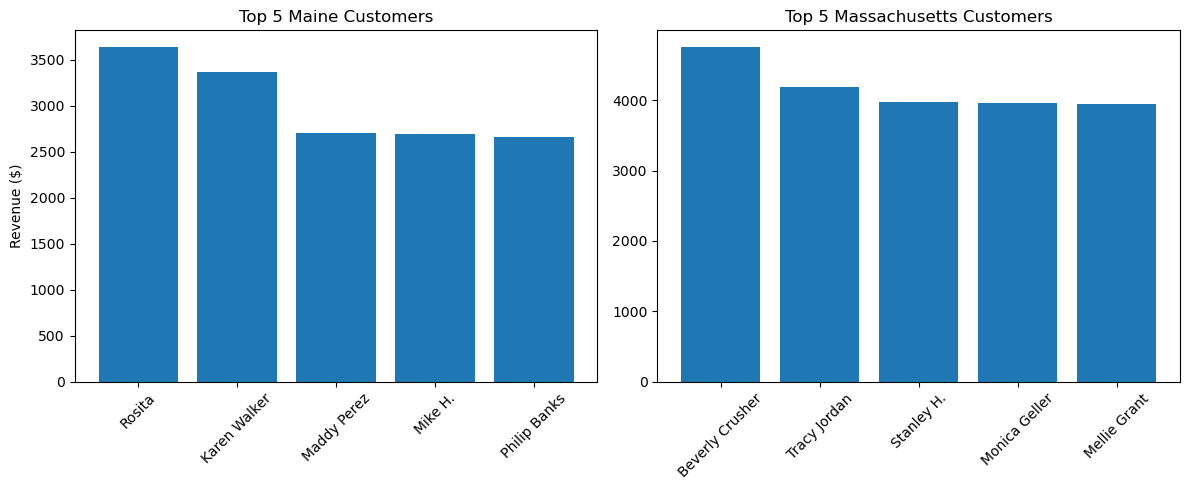

In [80]:
# get top 5 only
maine_top5 = maine_contribution[maine_contribution['Rank'] <= 5].sort_values('Rank')
mass_top5 = mass_contribution[mass_contribution['Rank'] <= 5].sort_values('Rank')

# create side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Maine chart
axes[0].bar(maine_top5['Name'], maine_top5['Sale Amount'])
axes[0].set_title('Top 5 Maine Customers')
axes[0].set_ylabel("Revenue ($)")
axes[0].tick_params(axis='x', rotation=45)

# Massachusetts chart
axes[1].bar(mass_top5['Name'], mass_top5['Sale Amount'])
axes[1].set_title('Top 5 Massachusetts Customers')
axes[1].tick_params(axis='x', rotation=45) # for readability

plt.tight_layout()
plt.show()

## ---------------------------------------------------------------------------------------------------------------------------------------------------

## Q5: Monthly Transaction & Revenue by Product Category

In [81]:
# This analysis examines the number of monthly transactions and total sales revenue by product category 
# across Maine and Massachusetts, allowing for the identification of the most popular products and key sales trends. 
# By comparing transaction volume and revenue, the analysis highlights which categories drive the most demand 
# and reveals potential opportunities for growth in lower-performing product areas.

In [82]:
# merge product info (get CategoryID)
territory_sales_cat = territory_sales.merge(
    products[['Prod Num', 'CategoryID']],
    on='Prod Num')

# merge category names
territory_sales_cat = territory_sales_cat.merge(
    product_categories[['CategoryID', 'Category']],
    on='CategoryID')

# group by State, Month, Category
monthly_cat_stats = territory_sales_cat.groupby(
    ['State', 'Month', 'Category']).agg(
    Transactions=('Prod Num', 'count'),
    Total_Revenue=('Sale Amount', 'sum')).reset_index()

# rank categories within each State and Month
monthly_cat_stats['Rank'] = monthly_cat_stats.groupby(
    ['State', 'Month'])['Total_Revenue'].rank(ascending=False, method='dense')

# sort results (makes output cleaner)
monthly_cat_stats = monthly_cat_stats.sort_values(
    ['State', 'Month', 'Rank'])

In [83]:
# filter Maine
maine_monthly_cat = monthly_cat_stats[
    monthly_cat_stats['State'] == 'Maine'
]

# sort by Month then Rank
maine_monthly_cat_sort = maine_monthly_cat.sort_values(['Month', 'Rank'])

# display
maine_monthly_cat_sort

,State,Month,Category,Transactions,Total_Revenue,Rank
4,Maine,2022-01,Technology & Accessories,42,6460.23,1.0
1,Maine,2022-01,Art Supplies,99,2892.89,2.0
5,Maine,2022-01,Textbooks,11,1890.90,3.0
0,Maine,2022-01,Apparel and Merchandise,32,665.28,4.0
3,Maine,2022-01,Stationery and Supplies,66,563.31,5.0
...,...,...,...,...,...,...
274,Maine,2025-12,Textbooks,33,6544.01,2.0
269,Maine,2025-12,Apparel and Merchandise,56,2427.36,3.0
270,Maine,2025-12,Art Supplies,55,1717.43,4.0
272,Maine,2025-12,Stationery and Supplies,110,1035.54,5.0


In [85]:
# filter Massachusetts
mass_monthly_cat = monthly_cat_stats[
    monthly_cat_stats['State'] == 'Massachusetts']

# sort by Month then Rank
mass_monthly_cat_sort = mass_monthly_cat.sort_values(['Month', 'Rank'])

# display
mass_monthly_cat_sort

,State,Month,Category,Transactions,Total_Revenue,Rank
279,Massachusetts,2022-01,Technology & Accessories,84,51545.62,1.0
280,Massachusetts,2022-01,Textbooks,110,20814.75,2.0
275,Massachusetts,2022-01,Apparel and Merchandise,80,2010.40,3.0
276,Massachusetts,2022-01,Art Supplies,77,1934.90,4.0
278,Massachusetts,2022-01,Stationery and Supplies,132,1390.07,5.0
...,...,...,...,...,...,...
562,Massachusetts,2025-12,Textbooks,176,28534.00,2.0
558,Massachusetts,2025-12,Art Supplies,275,8675.48,3.0
557,Massachusetts,2025-12,Apparel and Merchandise,144,5430.48,4.0
560,Massachusetts,2025-12,Stationery and Supplies,231,2214.30,5.0


### Bar Chart:

Average Revenue Per Category: Maine: $ 263158.04
Average Revenue Per Category: Massachusetts: $ 797969.68


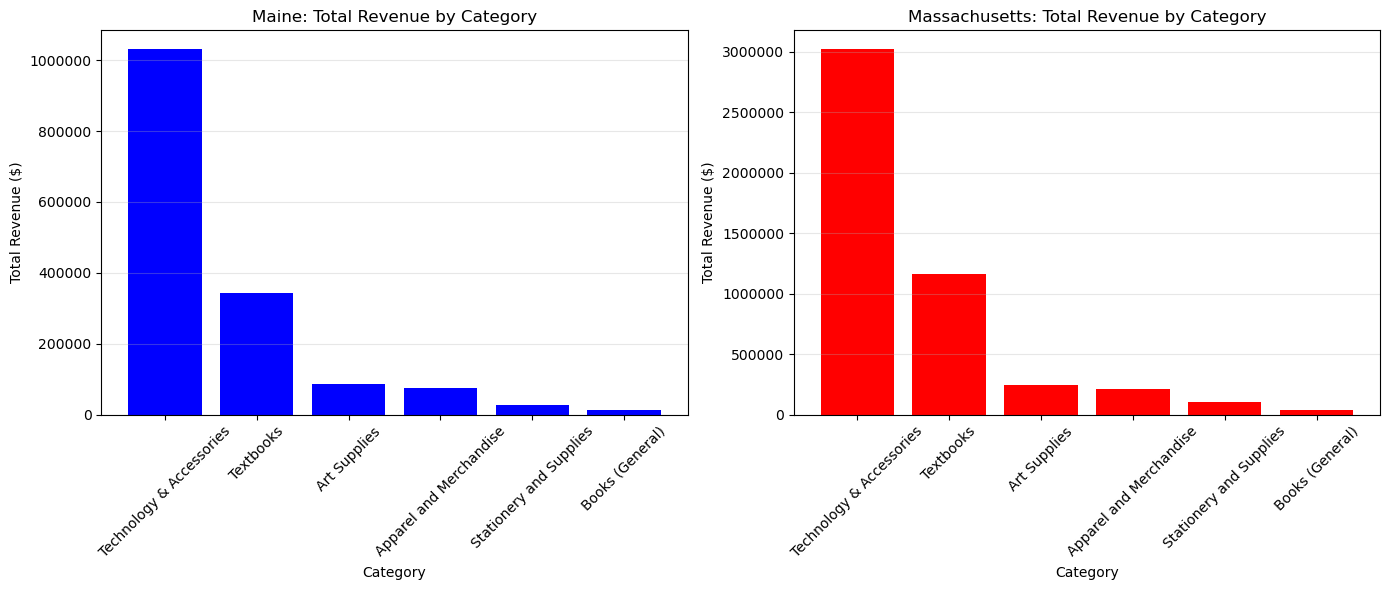

In [95]:
# group by category (total revenue)
maine_total_cat = maine_monthly_cat_sort.groupby('Category')['Total_Revenue'].sum().reset_index()
mass_total_cat = mass_monthly_cat_sort.groupby('Category')['Total_Revenue'].sum().reset_index()

# calculate averages (keeping your method)
maine_arr = np.array(maine_total_cat['Total_Revenue'])
mass_arr = np.array(mass_total_cat['Total_Revenue'])

maine_avg_rev = np.mean(maine_arr)
mass_avg_rev = np.mean(mass_arr)

# print results
print("Average Revenue Per Category: Maine: $", round(maine_avg_rev, 2))
print("Average Revenue Per Category: Massachusetts: $", round(mass_avg_rev, 2))

# sort for cleaner charts
maine_total_cat = maine_total_cat.sort_values('Total_Revenue', ascending=False)
mass_total_cat = mass_total_cat.sort_values('Total_Revenue', ascending=False)

# create side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Maine chart
axes[0].bar(maine_total_cat['Category'], maine_total_cat['Total_Revenue'], color='blue')
axes[0].set_title('Maine: Total Revenue by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].ticklabel_format(style='plain', axis='y') 
axes[0].grid(axis='y', alpha=0.3)

# Massachusetts chart
axes[1].bar(mass_total_cat['Category'], mass_total_cat['Total_Revenue'], color='red')
axes[1].set_title('Massachusetts: Total Revenue by Category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Total Revenue ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].ticklabel_format(style='plain', axis='y')  
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Analysis:
#### This indicates that Massachusetts generates about three times more revenue per category, highlighting a significantly stronger
#### and more productive market. Across both states, Technology & Accessories consistently ranks as the top revenue-generating
#### category, despite not always having the highest transaction volume. This suggests that products in this category are higher
#### priced and more profitable, making them key drivers of total revenue. Textbooks also perform strongly in both markets, 
#### indicating stable and consistent demand for academic-related products. In Maine, revenue levels across categories are lower
#### but more evenly distributed, with moderate transaction volumes and smaller revenue totals. This reflects a more balanced but
#### smaller-scale market, where no single category overwhelmingly dominates. In contrast, Massachusetts shows much higher transaction 
#### counts and significantly larger revenue totals across all major categories, especially in Technology & Accessories and Textbooks. 
#### This indicates a larger customer base, stronger demand, and greater purchasing power, leading to higher overall category performance.

## ---------------------------------------------------------------------------------------------------------------------------------------------

# Market Recommendation for Next Quarter:

### Marketing efforts should focus on maximizing high-revenue categories like Technology & Accessories,
### while increasing profitability in high-demand but lower-value categories such as Art Supplies. 
### Massachusetts should prioritize scalability and upselling due to its large customer base, 
### while Maine should focus on customer retention and targeted growth. Additionally, underperforming 
### categories and seasonal trends present key opportunities for expansion and revenue growth.

